In [1]:
%load_ext autoreload
%autoreload 2 

## Imports

In [3]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax
import pickle
import sys

sys.path.append("py-files")

In [4]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [5]:
import solve
import aux_ as aux
import RANK
import model_funcs
import neural_nets
import plotting

In [6]:
do_solve = False
do_save = False

## Device

In [7]:
device = aux.choose_gpu()

Avaliable devices:


cuBLAS < 13.2 (120902 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


cuda:0

Device = cuda:0 is choosen


## Training the neural network to the DSS and SSS

In [8]:
model = RANK.RANK_model(device)

In [9]:
sigma_eps_u = 0.001350
sigma_eps_z = 0.020814
sigma_eps_Gamma = 0.012778

sigma_quad = {
    "sigma_eps_u" : sigma_eps_u,
    "sigma_eps_z" :  sigma_eps_z,
    "sigma_eps_Gamma" : sigma_eps_Gamma
}

factor = 1.0
sigma_sim = {
    "sigma_eps_u" : factor*sigma_eps_u,
    "sigma_eps_z" :  factor*sigma_eps_z,
    "sigma_eps_Gamma" : factor*sigma_eps_Gamma
}

episode_list = [5_000, 2_500_000, 100_000]
lr_list = [5e-4, 5e-4, 1e-4]
N_list = [1000, 2500, 10000]
ZLB_list = [-1, -0.005, -0.005, 0.00]

In [10]:
if do_solve: solve.train_nn(model, episode_list, sigma_sim, sigma_quad, ZLB_list, lr_list, N_list, print_freq=100)

In [11]:
if (do_solve and do_save): model.save('output/final_nn.pkl', model.nn)

In [12]:
if not do_solve: model.load('output/final_nn.pkl', opt_load=False)

# Plots

In [13]:
if (do_solve and do_save):
    for k,v in model.info.items():
        with open('output/info_'+ k+'.pkl', 'wb') as f:
            pickle.dump(v, f)

else:
    info = {}
    for k in ['train_losses', 'test_losses', 'ee_test_losses', 'nkpce_test_losses']:
        with open('output/info_' + k + '.pkl', 'rb') as f:
            info[k] = pickle.load(f)

            model.info = info

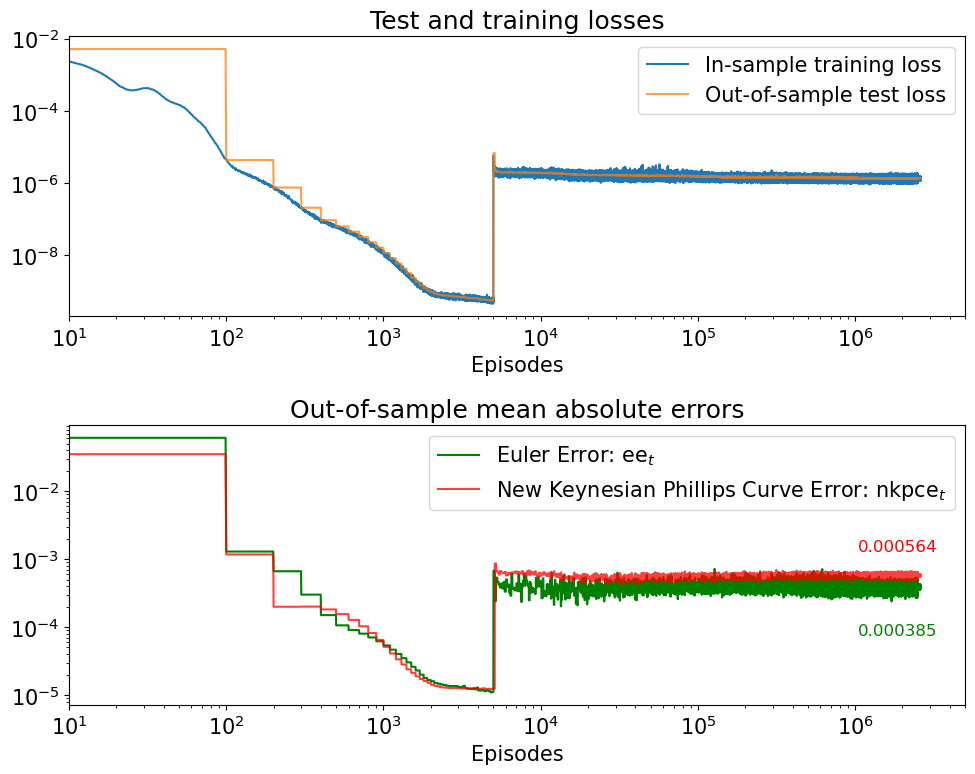

In [19]:
plt.rcParams.update({'font.size': 15})

f, ax = plt.subplots(2,1,figsize=(10,8))

ax[0].plot(model.info['train_losses'], label=r'In-sample training loss')
ax[0].plot(model.info['test_losses'], alpha=0.75, label=r'Out-of-sample test loss')

ax[1].plot(model.info['ee_test_losses'], color='green', label=r'Euler Error: $\text{ee}_t$')
ax[1].plot(model.info['nkpce_test_losses'], alpha=0.75, color='red', label=r'New Keynesian Phillips Curve Error: $\text{nkpce}_t$')

xticks = [
    50_000,
    0.5*10**6,
    10**6,
    1.5*10**6,
    2*10**6,
    2.5*10**6
]

xlabels = [
    r'$50 \ 000$',
    r'$0.5\times10^6$',
    r'$1.0\times10^6$',
    r'$1.5\times10^6$',
    r'$2\times10^6$',
    r'$2.5\times10^6$'
]

for i in range(2):
    ax[i].set_xlim([10, 5*1e6])
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
    #ax[i].set_xticks(xticks)
    #ax[i].set_xticklabels(xlabels)
    ax[i].set_xlabel('Episodes')
    ax[i].legend()

ax[0].set_title(r'Test and training losses')
ax[1].set_title(r'Out-of-sample mean absolute errors')

ax[1].text(0.88, 0.55, f'{model.info["nkpce_test_losses"][-1]:.6f}', 
           transform=ax[1].transAxes, color='red', fontsize=12)

ax[1].text(0.88, 0.25, f'{model.info["ee_test_losses"][-1]:.6f}', 
           transform=ax[1].transAxes, color='green', fontsize=12)

f.tight_layout()

if do_save: f.savefig('plots/training_nns.png', bbox_inches='tight')